In [8]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
df = pd.read_csv("data.csv", encoding="latin1")
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


In [21]:
missing = (df.isnull().sum() / len(df)) * 100
missing

InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
Total           0.000000
dtype: float64

In [22]:
dfc = df.copy()
dfc = dfc.dropna(subset = ['Description'])
dfc = dfc.dropna(subset = ['CustomerID'])
dfc = dfc[dfc["Quantity"]>0]
dfc = dfc[dfc["UnitPrice"]>0]
dfc['InvoiceDate'] = pd.to_datetime(dfc['InvoiceDate'])

In [24]:
dfc.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Total          0
dtype: int64

# Recency

In [ ]:
dfc['Total'] = dfc['Quantity'] * dfc['UnitPrice']
print(dfc['Total'].head(3))

0    15.30
1    20.34
2    22.00
Name: Total, dtype: float64


In [25]:
reference_date = dfc["InvoiceDate"].max() + pd.Timedelta(days=1) # To choose the next date of the maximum date from the dataset as the reference date for calculation
recency = reference_date - dfc["InvoiceDate"]

# Frequency and Monetary

In [26]:
rfm = dfc.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "InvoiceNo": "nunique",
    "Total": "sum"
})

rfm.rename(columns={
    "InvoiceDate": "Recency",
    "InvoiceNo": "Frequency",
    "Total": "Monetary"
}, inplace=True)

# Top Product Purchased

In [28]:
top_product = dfc.groupby(["CustomerID", "Description"])["Quantity"].sum().reset_index()

In [29]:
top_product = top_product.sort_values(
    ["CustomerID", "Quantity"],
    ascending=[True, False]
)
top_product = top_product.drop_duplicates("CustomerID")

In [30]:
top_product = top_product[["CustomerID", "Description"]]

top_product.rename(columns={
    "ProductName": "Top_Product"
}, inplace=True)

# Combine RFM + Top Product

In [ ]:
rfm = rfm.reset_index()
customer_features = rfm.merge(top_product, on="CustomerID", how="left")
customer_features.head()

,CustomerID,Recency,Frequency,Monetary,Description
0,12346.0,326,1,77183.60,MEDIUM CERAMIC TOP STORAGE JAR
1,12347.0,2,7,4310.00,ICE CREAM SUNDAE LIP GLOSS
2,12348.0,75,4,1797.24,DOUGHNUT LIP GLOSS
3,12349.0,19,1,1757.55,STRAWBERRY CERAMIC TRINKET POT
4,12350.0,310,1,334.40,TEA BAG PLATE RED RETROSPOT


# Customer Category Labeling 
#### Champions, Loyal Customer, Occasional Buyers, Inactive Customers

In [32]:
X = customer_features[["Recency", "Frequency", "Monetary"]]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() # We are scaling the Value because  Monetary has big values and it may dominate the clustering
X_scaled = scaler.fit_transform(X)

## k-means clustering

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

customer_features["Cluster"] = kmeans.fit_predict(X_scaled) # now each customer will get each values= 0,1,2,3

In [35]:
cluster_summary = customer_features.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1359.049284
1,248.075914,1.552015,480.617480
2,7.384615,82.538462,127338.313846
3,15.500000,22.333333,12709.090490


### From the cluster summary, 
### 2 - Champions (Low Recency -> High Frequency -> High Monetary)
### 3 - Loyal Customers (Mid Recency -> High Frequency -> High Monetary)
### 0 - Occasional Buyers (High Recency -> Low Frequency -> Low Monetary)
### 1 - Inactive Customers (Very High Recency -> Very Low Frequency -> Very Low Monetary)

In [36]:
segment_map = {
    2: "Champions",
    3: "Loyal Customers",
    0: "Occasional Buyers",
    1: "Inactive Customers"
}

customer_features["Segment"] = customer_features["Cluster"].map(segment_map)

customer_features.head()

,CustomerID,Recency,Frequency,Monetary,Description,Cluster,Segment
0,12346.0,326,1,77183.60,MEDIUM CERAMIC TOP STORAGE JAR,3,Loyal Customers
1,12347.0,2,7,4310.00,ICE CREAM SUNDAE LIP GLOSS,0,Occasional Buyers
2,12348.0,75,4,1797.24,DOUGHNUT LIP GLOSS,0,Occasional Buyers
3,12349.0,19,1,1757.55,STRAWBERRY CERAMIC TRINKET POT,0,Occasional Buyers
4,12350.0,310,1,334.40,TEA BAG PLATE RED RETROSPOT,1,Inactive Customers


In [52]:
segment_counts = customer_features["Segment"].value_counts()
segment_counts

Segment
Occasional Buyers     3054
Inactive Customers    1067
Loyal Customers        204
Champions               13
Name: count, dtype: int64

## Campaign Message Generator

In [45]:
def generate_campaign(row):
    segment = row["Segment"]
    product = row["Description"]

    if pd.isna(product):
        product = "your favorite products"

    if segment == "Champions / VIP Customers":
        campaign_goal = "Reward and retain high-value customers"
        message = f"Thank you for being one of our top customers! Enjoy an exclusive VIP reward on {product}."

    elif segment == "Loyal Customers":
        campaign_goal = "Increase repeat purchases"
        message = f"We appreciate your loyalty! Get a special offer on {product} and continue enjoying your favorite picks."

    elif segment == "Occasional Buyers / Need Attention":
        campaign_goal = "Encourage more frequent purchases"
        message = f"Still interested in {product}? Here is a limited-time personalized offer just for you."

    elif segment == "Inactive / Lost Customers":
        campaign_goal = "Win back inactive customers"
        message = f"We miss you! Come back and enjoy a special discount on {product}."

    else:
        campaign_goal = "General engagement"
        message = "Explore our latest offers selected specially for you."

    return pd.Series([campaign_goal, message])

In [46]:
customer_features[["Campaign_Goal", "Campaign_Message"]] = customer_features.apply(
    generate_campaign,
    axis=1
)
customer_features[
    ["CustomerID", "Segment", "Description", "Campaign_Goal", "Campaign_Message"]
].head(10)

,CustomerID,Segment,Description,Campaign_Goal,Campaign_Message
0,12346.0,Loyal Customers,MEDIUM CERAMIC TOP STORAGE JAR,Increase repeat purchases,We appreciate your loyalty! Get a special offe...
1,12347.0,Occasional Buyers,ICE CREAM SUNDAE LIP GLOSS,General engagement,Explore our latest offers selected specially f...
2,12348.0,Occasional Buyers,DOUGHNUT LIP GLOSS,General engagement,Explore our latest offers selected specially f...
3,12349.0,Occasional Buyers,STRAWBERRY CERAMIC TRINKET POT,General engagement,Explore our latest offers selected specially f...
4,12350.0,Inactive Customers,TEA BAG PLATE RED RETROSPOT,General engagement,Explore our latest offers selected specially f...
5,12352.0,Occasional Buyers,PINK HEART SHAPE EGG FRYING PAN,General engagement,Explore our latest offers selected specially f...
6,12353.0,Inactive Customers,MINI CAKE STAND WITH HANGING CAKES,General engagement,Explore our latest offers selected specially f...
7,12354.0,Inactive Customers,BLUE POLKADOT CUP,General engagement,Explore our latest offers selected specially f...
8,12355.0,Inactive Customers,ICE CREAM SUNDAE LIP GLOSS,General engagement,Explore our latest offers selected specially f...
9,12356.0,Occasional Buyers,60 TEATIME FAIRY CAKE CASES,General engagement,Explore our latest offers selected specially f...


In [49]:
segment_summary = customer_features.groupby("Segment").agg({
    "CustomerID": "count",
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean"
}).round(2)

segment_summary

segment_summary = segment_summary.rename(columns={
    "CustomerID": "Customer_Count",
    "Recency": "Avg_Recency",
    "Frequency": "Avg_Frequency",
    "Monetary": "Avg_Monetary"
})

segment_summary

,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,,
Champions,13,7.38,82.54,127338.31
Inactive Customers,1067,248.08,1.55,480.62
Loyal Customers,204,15.50,22.33,12709.09
Occasional Buyers,3054,43.70,3.68,1359.05


# Visualization

### Which Customer Segment Needs Attention ?

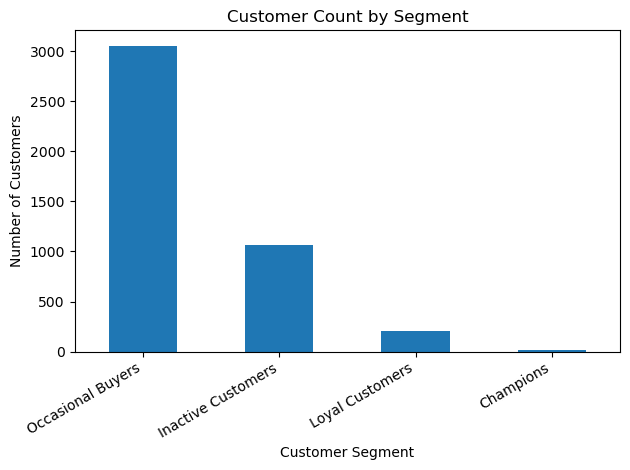

In [53]:
import matplotlib.pyplot as plt

segment_counts.plot(kind="bar")

plt.title("Customer Count by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Which Segment has the highest Average Monetary ?

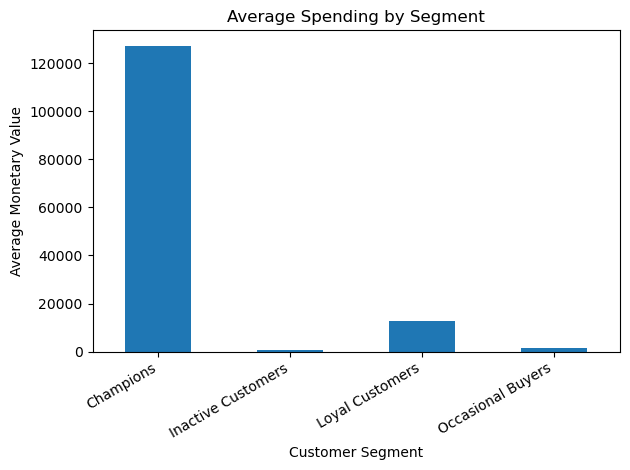

In [54]:
segment_summary["Avg_Monetary"].plot(kind="bar")

plt.title("Average Spending by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Monetary Value")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Final Campaign Output

In [56]:
final_output = customer_features[
    ["CustomerID", "Segment", "Description", "Campaign_Goal", "Campaign_Message"]
]

final_output.head(10)

,CustomerID,Segment,Description,Campaign_Goal,Campaign_Message
0,12346.0,Loyal Customers,MEDIUM CERAMIC TOP STORAGE JAR,Increase repeat purchases,We appreciate your loyalty! Get a special offe...
1,12347.0,Occasional Buyers,ICE CREAM SUNDAE LIP GLOSS,General engagement,Explore our latest offers selected specially f...
2,12348.0,Occasional Buyers,DOUGHNUT LIP GLOSS,General engagement,Explore our latest offers selected specially f...
3,12349.0,Occasional Buyers,STRAWBERRY CERAMIC TRINKET POT,General engagement,Explore our latest offers selected specially f...
4,12350.0,Inactive Customers,TEA BAG PLATE RED RETROSPOT,General engagement,Explore our latest offers selected specially f...
5,12352.0,Occasional Buyers,PINK HEART SHAPE EGG FRYING PAN,General engagement,Explore our latest offers selected specially f...
6,12353.0,Inactive Customers,MINI CAKE STAND WITH HANGING CAKES,General engagement,Explore our latest offers selected specially f...
7,12354.0,Inactive Customers,BLUE POLKADOT CUP,General engagement,Explore our latest offers selected specially f...
8,12355.0,Inactive Customers,ICE CREAM SUNDAE LIP GLOSS,General engagement,Explore our latest offers selected specially f...
9,12356.0,Occasional Buyers,60 TEATIME FAIRY CAKE CASES,General engagement,Explore our latest offers selected specially f...


## Final Output File

In [57]:
final_output.to_csv("marketing_campaigns.csv", index=False)